In [34]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import tensorflow as tf
from tensorflow.keras import Sequential
from tensorflow.keras.models import load_model
from tensorflow.keras.layers import (Dense, Flatten, Dropout, Conv2D, MaxPooling2D)
from tensorflow.keras.utils import to_categorical, plot_model
from tensorflow.keras.preprocessing.image import ImageDataGenerator

from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix, classification_report


# Redes Neurais Convolucionais

## Carregando o Dataset

Vamos usar o dataset CIFAR 10, o mesmo é um dataset de classificação de imagensonde temos as seguintes classes disponíveis:

*   Aviões
*   carros
*   passaros
*   gatos
*   veados
*   cachorros
*   sapos
*   cavalos
*   návios
*   caminhões



<center>
<img src='https://drive.google.com/uc?id=1yIihwCkW511n8A4o-JMfLjD4KKJw7m9a'width=700>


Será que conseguimos criar um sistema de classificação para imagens, onde dada uma imagem de entrada, classificamos ela entre uma das 10 classes anteriores?

Vamos  iniciar recebendo essas imagens:

In [35]:
(train_images, train_labels), (test_images, test_labels) = tf.keras.datasets.cifar10.load_data()

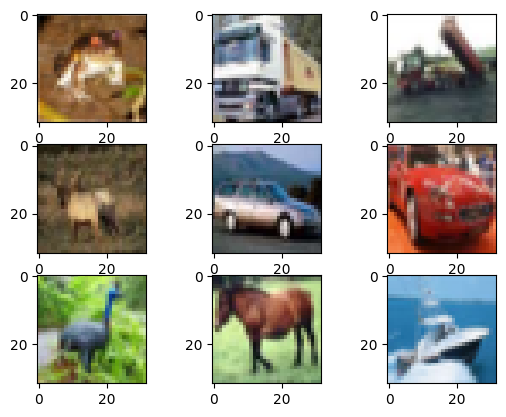

In [36]:
for i in range(9):
	# define subplot
	plt.subplot(330 + 1 + i)
	# plot raw pixel data
	plt.imshow(train_images[i])
# show the figure
plt.show()

In [37]:
train_images.shape

(50000, 32, 32, 3)

In [38]:
test_images.shape

(10000, 32, 32, 3)

Temos um total de 50000 imagens diferentes com dimensão de 32x32x3 pixels

In [39]:
train_labels

array([[6],
       [9],
       [9],
       ...,
       [9],
       [1],
       [1]], dtype=uint8)

In [40]:
train_labels = tf.keras.utils.to_categorical(train_labels)
train_labels.shape

(50000, 10)

In [41]:
train_labels

array([[0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 1.],
       [0., 0., 0., ..., 0., 0., 1.],
       ...,
       [0., 0., 0., ..., 0., 0., 1.],
       [0., 1., 0., ..., 0., 0., 0.],
       [0., 1., 0., ..., 0., 0., 0.]])

In [42]:
test_labels = tf.keras.utils.to_categorical(test_labels)
test_labels.shape

(10000, 10)

In [43]:
# Normalizando os valores dos pixel para serem entre 0 e 1
train_images, test_images = train_images / 255.0, test_images / 255.0

## Criando o modelo

Para processamento de imagens podemos usar redes neurais convolucionais. Esse tipo de rede tem seus parâmetros em uma matriz (*kernel*) que processa toda a imagem passando por todos os seus pixels. Essa matriz são os parâmetros que serão aprendidos pela rede

<center>
<img src='https://drive.google.com/uc?id=15kidvb-4BozzWN9_AfIbxKJftezkKK4U'width=1000>


Podemos perceber que a convolução é uma operação que pode reduzir a dimensão da entrada, uma vez que tinhamos uma imagem de 7x7 pixels na entrada e como saída final ficamos com 5x5 pixels

No exemplo acima temos uma convolução ocorrendo numa imagem com um único canal. Entretanto, uma das formas de representações é o espaço de cores RGB. A imagem abaixo ilustra o exemplo da clássica imagem da lenna nesse espaço de cores:

<center>
<img src='https://drive.google.com/uc?id=1S-oIn5WmGyr6Xg5Cc4hs4PvCrncXoZw2'width=700>



A união dos três canais forma a imagem colorida (256x256x3). Dessa forma a convolução irá operar nos três canais, tendo um *kernel* para cada canal:

<center>
<img src='https://drive.google.com/uc?id=1KALsA9iuIDkaURYEmgu1XD69hz04siyG'width=700>


O exemplo acima é aplicado quande deseja-se transformar os três canais de convolução em uma única saída.

Vamos agora criar o nosso modelo:

In [44]:
modelo = tf.keras.Sequential()

modelo.add(Conv2D(16, (3, 3), activation='relu', input_shape=(32, 32, 3)))
modelo.add(Conv2D(32, (3, 3), activation='relu'))
modelo.add(MaxPooling2D((2, 2),))
modelo.add(Conv2D(32, (3, 3), activation='relu'))
modelo.add(Flatten())
modelo.add(Dense(16, activation='relu'))
modelo.add(Dense(10, activation='softmax'))

modelo.compile(optimizer="adam", loss="categorical_crossentropy", metrics=["accuracy"])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Temos uma camada de Max Pooling. Essa camada é utilizada para fazer com que a rede seja invariante a pequenas alterações na posição da imagem nos pixels de entrada.

<center>
<img src='https://drive.google.com/uc?id=1G96qhP-Z6piTvWrPopfGxzfkvSthNPOO'width=700>

Temos também a camada de Flatten que apenas irá transformar a saída da convolução que é bidimensional em uma dimensão. Isso é feito para que posteriormente seja possível implementar uma rede neural densa, já que esse espera como entrada um vetor

<center>
<img src='https://drive.google.com/uc?id=1jG7b_oFVFdFSXwcOEuMabzKb7SpvXZrb'width=500>

In [45]:
modelo.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_9 (Conv2D)               │ (None, 30, 30, 16)     │           448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_10 (Conv2D)              │ (None, 28, 28, 32)     │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_11 (Conv2D)              │ (None, 12, 12, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 4608)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 16)             │        73,744 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 10)             │           170 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 88,250 (344.73 KB)

 Trainable params: 88,250 (344.73 KB)

 Non-trainable params: 0 (0.00 B)

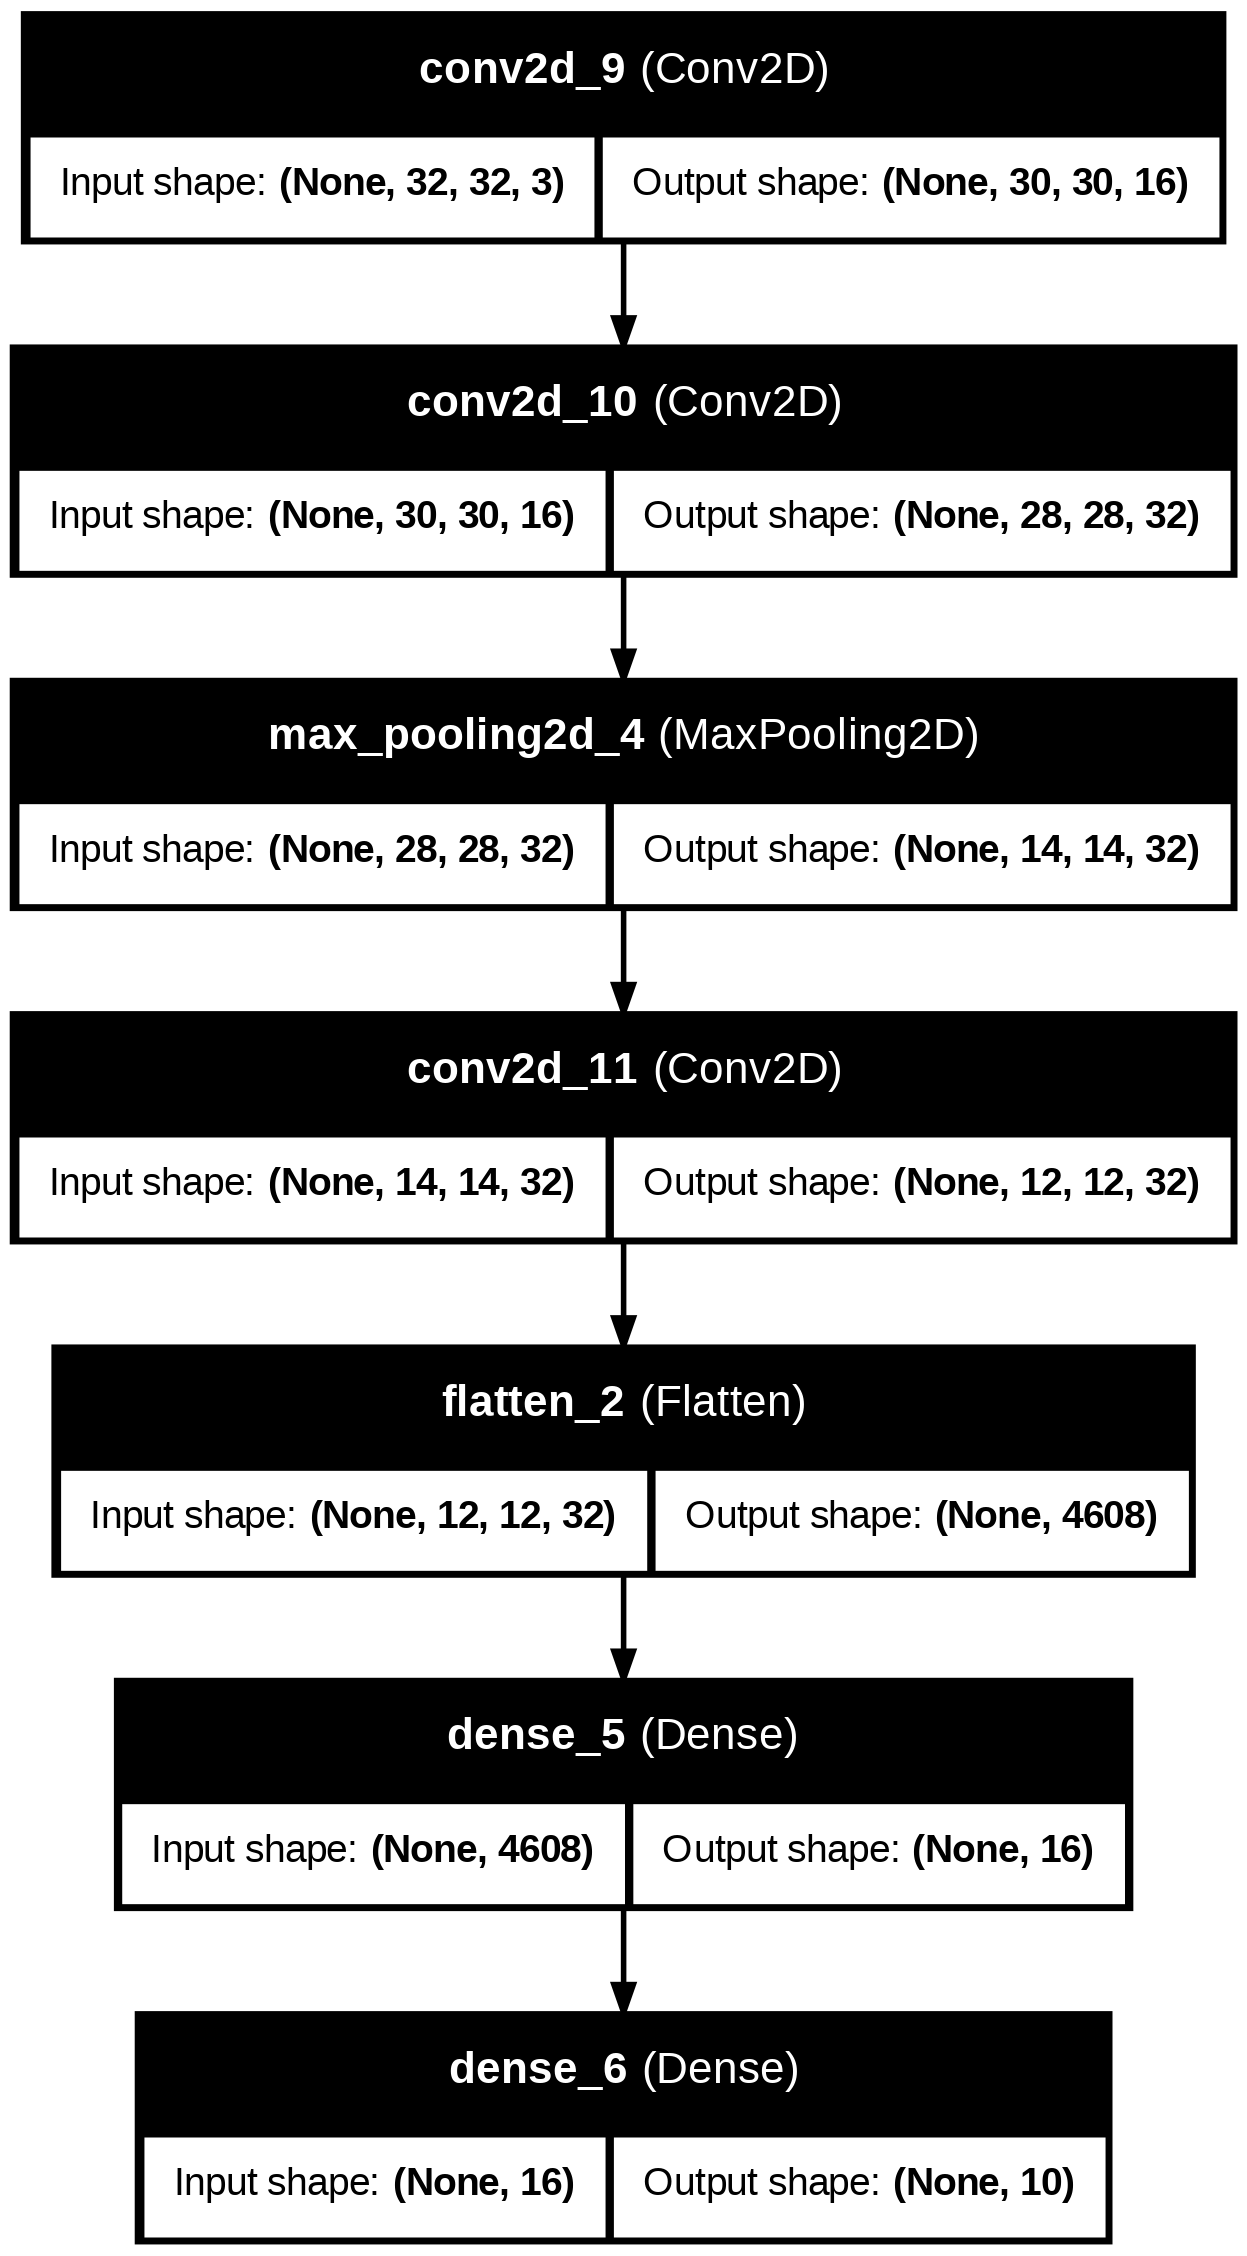

In [46]:
plot_model(modelo, to_file='model_plot.png', show_shapes=True, show_layer_names=True)

Realizando o treinamento:

In [47]:
# Vamos fazer o treinamento utilizando 35 epocas!
history = modelo.fit(train_images,train_labels,epochs=30, verbose=1, batch_size=120, validation_split=0.2)

Epoch 1/30
334/334 ━━━━━━━━━━━━━━━━━━━━ 7s 13ms/step - accuracy: 0.2336 - loss: 2.0601 - val_accuracy: 0.4514 - val_loss: 1.5091
Epoch 2/30
334/334 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.4721 - loss: 1.4538 - val_accuracy: 0.5345 - val_loss: 1.3082
Epoch 3/30
334/334 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.5446 - loss: 1.2695 - val_accuracy: 0.5615 - val_loss: 1.2076
Epoch 4/30
334/334 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.5874 - loss: 1.1533 - val_accuracy: 0.5900 - val_loss: 1.1537
Epoch 5/30
334/334 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.6145 - loss: 1.0707 - val_accuracy: 0.6014 - val_loss: 1.1239
Epoch 6/30
334/334 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.6340 - loss: 1.0197 - val_accuracy: 0.6272 - val_loss: 1.0599
Epoch 7/30
334/334 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.6546 - loss: 0.9620 - val_accuracy: 0.6377 - val_loss: 1.0353
Epoch 8/30
334/334 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.6676 - loss: 0.9253 - val_accuracy: 0

In [48]:
modelo.save('CNN_Classificador.h5')

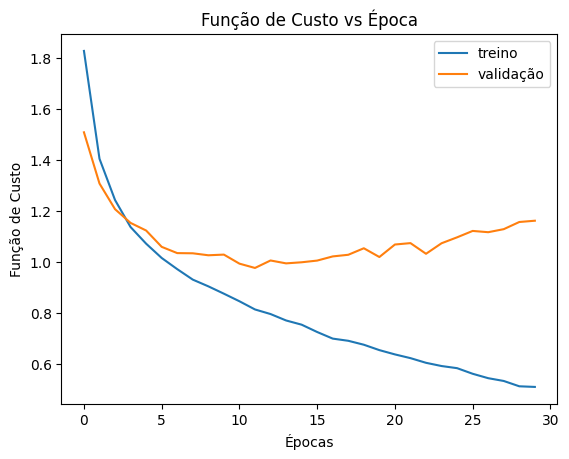

In [49]:
# Plotando o MSE para cada época de treinamento
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('Função de Custo vs Época')
plt.ylabel('Função de Custo')
plt.xlabel('Épocas')
plt.legend(['treino', 'validação'], loc='upper right')
plt.show()

Podemos perceber que nesse primeiro treinamento houve um overfitting, uma vez que o confjunto de validação após 10 épocas de treinamento começou a aumentar o valor da sua função custo

## Criando um novo modelo

Agora vamos criar um segundo novo modelo para tentar conseguir um resultado diferente no treinamento:

In [50]:
model= tf.keras.Sequential()

model.add(Conv2D(32, (3, 3), input_shape=(32,32,3), activation='relu', padding='same'))
model.add(Dropout(0.2))
model.add(Conv2D(32, (3, 3), activation='relu', padding='same'))
model.add(MaxPooling2D(pool_size=(2, 2)))
model.add(Conv2D(64, (3, 3), activation='relu', padding='same'))
model.add(Dropout(0.2))
model.add(Conv2D(64, (3, 3), activation='relu', padding='same'))
model.add(MaxPooling2D(pool_size=(2, 2)))
model.add(Conv2D(128, (3, 3), activation='relu', padding='same'))
model.add(Dropout(0.2))
model.add(Conv2D(128, (3, 3), activation='relu', padding='same'))
model.add(MaxPooling2D(pool_size=(2, 2)))
model.add(Flatten())
model.add(Dropout(0.2))
model.add(Dense(1024, activation='relu'))
model.add(Dropout(0.2))
model.add(Dense(512, activation='relu'))
model.add(Dropout(0.2))
model.add(Dense(10, activation='softmax'))

model.compile(optimizer="adam", loss="categorical_crossentropy", metrics=["accuracy"])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [51]:
model.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_12 (Conv2D)              │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_13 (Conv2D)              │ (None, 32, 32, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_14 (Conv2D)              │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_15 (Conv2D)              │ (None, 16, 16, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_16 (Conv2D)              │ (None, 8, 8, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_8 (Dropout)             │ (None, 8, 8, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_17 (Conv2D)              │ (None, 8, 8, 128)      │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_7 (MaxPooling2D)  │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_3 (Flatten)             │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_9 (Dropout)             │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 1024)           │     2,098,176 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_10 (Dropout)            │ (None, 1024)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 512)            │       524,800 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_11 (Dropout)            │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 10)             │         5,130 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,915,114 (11.12 MB)

 Trainable params: 2,915,114 (11.12 MB)

 Non-trainable params: 0 (0.00 B)

O padding é uma forma de realizar a convolução sem alterar a dimensão da saída da operação de convolução:

<center>
<img src='https://drive.google.com/uc?id=1pxfS3V9DquLJNIvx3LupZz12KBm5NtIO'width=800>

O Dropout é uma técnica que faz com que alguns neurônios seja desativados aleatoriamente durante o treinamento. O objetivo disso é que evitar o Overfitting. Seria o similar a treinarmos diferentes redes e obtermos a média delas como saída. No caso o dropout irá eliminar 20% dos neurônios durante o treinamento.

Realizando o novo treinamento;

In [52]:
# Vamos fazer o treinamento utilizando 10 epocas!
history_2 = model.fit(train_images,train_labels,epochs=10, verbose=1, batch_size=120, validation_split=0.2)

Epoch 1/10
334/334 ━━━━━━━━━━━━━━━━━━━━ 21s 37ms/step - accuracy: 0.2369 - loss: 2.0216 - val_accuracy: 0.4677 - val_loss: 1.4454
Epoch 2/10
334/334 ━━━━━━━━━━━━━━━━━━━━ 5s 14ms/step - accuracy: 0.4912 - loss: 1.3920 - val_accuracy: 0.5695 - val_loss: 1.2128
Epoch 3/10
334/334 ━━━━━━━━━━━━━━━━━━━━ 5s 14ms/step - accuracy: 0.5924 - loss: 1.1388 - val_accuracy: 0.6458 - val_loss: 1.0102
Epoch 4/10
334/334 ━━━━━━━━━━━━━━━━━━━━ 5s 14ms/step - accuracy: 0.6480 - loss: 0.9857 - val_accuracy: 0.6829 - val_loss: 0.8874
Epoch 5/10
334/334 ━━━━━━━━━━━━━━━━━━━━ 5s 14ms/step - accuracy: 0.6950 - loss: 0.8652 - val_accuracy: 0.7283 - val_loss: 0.7760
Epoch 6/10
334/334 ━━━━━━━━━━━━━━━━━━━━ 5s 14ms/step - accuracy: 0.7316 - loss: 0.7670 - val_accuracy: 0.7203 - val_loss: 0.7988
Epoch 7/10
334/334 ━━━━━━━━━━━━━━━━━━━━ 5s 14ms/step - accuracy: 0.7575 - loss: 0.6852 - val_accuracy: 0.7417 - val_loss: 0.7303
Epoch 8/10
334/334 ━━━━━━━━━━━━━━━━━━━━ 5s 15ms/step - accuracy: 0.7826 - loss: 0.6158 - val_acc

In [53]:
model.save('CNN_Classificador_2.h5')

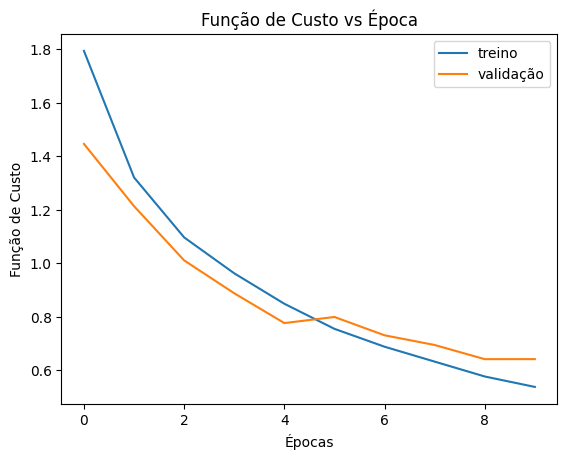

In [54]:
# Plotando o MSE para cada época de treinamento
plt.plot(history_2.history['loss'])
plt.plot(history_2.history['val_loss'])
plt.title('Função de Custo vs Época')
plt.ylabel('Função de Custo')
plt.xlabel('Épocas')
plt.legend(['treino', 'validação'], loc='upper right')
plt.show()

## Checando as métricas de desempenho

Realizando as previsões de todos os valores de saída para o conjunto de teste:

In [55]:
novo_modelo = load_model('CNN_Classificador_2.h5')

In [56]:
y_pred = novo_modelo.predict(test_images).argmax(axis=1)
y_pred

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step


array([3, 8, 8, ..., 5, 1, 7])

In [57]:
cm_rn = confusion_matrix(test_labels.argmax(axis=1), y_pred, labels = [0,1,2,3,4,5,6,7,8,9])
cm_rn

array([[836,  15,  35,  19,  12,   7,   7,  13,  39,  17],
       [  8, 908,   4,  12,   1,   4,   5,   3,  13,  42],
       [ 61,   2, 696,  46,  50,  62,  57,  18,   7,   1],
       [ 14,   4,  70, 636,  34, 158,  56,  23,   1,   4],
       [ 20,   1,  80,  74, 694,  29,  45,  55,   2,   0],
       [  9,   2,  45, 151,  23, 724,  18,  25,   1,   2],
       [  8,   2,  40,  65,  10,  19, 849,   4,   2,   1],
       [  6,   2,  29,  48,  44,  52,   3, 815,   0,   1],
       [ 71,  27,  17,  18,   7,   8,   4,   5, 827,  16],
       [ 29,  88,   4,  33,   4,  15,   7,  10,   9, 801]])

<Figure size 3000x2000 with 0 Axes>

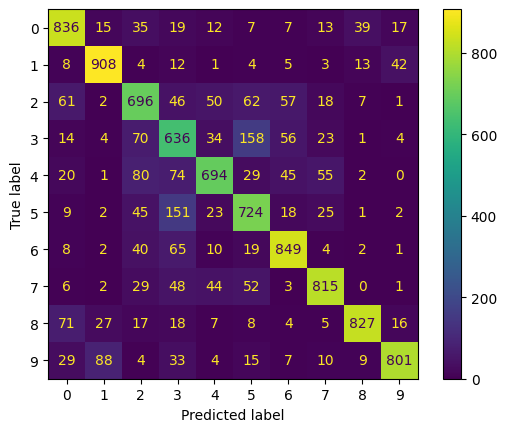

In [58]:
figure = plt.figure(figsize=(30, 20))
disp = ConfusionMatrixDisplay(confusion_matrix = cm_rn, display_labels=[0,1,2,3,4,5,6,7,8,9])
disp.plot(values_format='d')

In [59]:
# Metricas de precisão, revocação, f1-score e acurácia.
print(classification_report(test_labels.argmax(axis=1), y_pred))

              precision    recall  f1-score   support

           0       0.79      0.84      0.81      1000
           1       0.86      0.91      0.89      1000
           2       0.68      0.70      0.69      1000
           3       0.58      0.64      0.61      1000
           4       0.79      0.69      0.74      1000
           5       0.67      0.72      0.70      1000
           6       0.81      0.85      0.83      1000
           7       0.84      0.81      0.83      1000
           8       0.92      0.83      0.87      1000
           9       0.91      0.80      0.85      1000

    accuracy                           0.78     10000
   macro avg       0.78      0.78      0.78     10000
weighted avg       0.78      0.78      0.78     10000

